# Multi-Element DG Advection: h-Refinement Convergence

**Status:** ✅ **VECTORIZED MULTI-ELEMENT ARCHITECTURE** (2026-04-10)

**Reference Framework:** Hesthaven-Warburton (HW) standard **[-1,1]×[-1,1]** simplex

**Computational Strategy:** Fully vectorized (NO element loops), h-refinement convergence validation

## 🎯 Blueprint Compliance

This notebook strictly adheres to the Multi-Element DG architectural blueprint:

1. **Data Structures**:
   - Global state: `Q` with shape `(n_var, Np, K)` where `n_var=1` (scalar advection)
   - Geometric metrics: `J, rx, ry, sx, sy` as 1D arrays of shape `(K,)`
   - Interface topology: `vmapM` (interior), `vmapP` (exterior with [::-1] reversal), `mapB` (boundary mask)

2. **Absolute Vectorization**:
   - Zero `for k in range(K)` loops in RHS computation
   - All operations use NumPy broadcasting: `rx[np.newaxis, :]` for shape `(Np, K)`

3. **Exact LSRK54 Time Stepping**:
   - Global CFL: `dt_global = CFL * min(h_min_array) / (V_max * N²)`
   - Precise stopping: `while t < t_final - tol` with `current_dt = min(dt_global, t_final - t)`

4. **Convergence Validation**:
   - h-refinement loop over multiple mesh resolutions
   - Pandas DataFrame output with standardized formatting
   - Expected: $O(h^{k+1})$ spatial convergence

## 📐 Problem Formulation

**Scalar Transport Equation:**
$$\frac{\partial q}{\partial t} + \boldsymbol{V} \cdot \nabla q = 0$$

**Test Case:** Dynamic wave $q_\text{exact}(x,y,t) = \sin(x - t)$ with $\boldsymbol{V} = (1, 0)$ (pure x-advection).

## 📚 References

1. Cockburn et al. (2000). *Runge-Kutta Discontinuous Galerkin Methods*
2. Hesthaven & Warburton (2008). *Nodal DG Methods*

In [35]:
# ============================================================================
# CELL 1: Imports, Mesh Generation, Topological Connectivity
# ============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display
import sys

# Add src to path
notebook_dir = Path("/Users/user/code/Simplex-DG-solver/notebooks/experimental")
project_root = notebook_dir.parent.parent
sys.path.insert(0, str(project_root))

# Import core utilities
from src.core.generators import get_reference_data
from src.core.connectivity import build_connectivity
from src.geometry.metrics import compute_geometric_factors
from src.bases.simplex_2d import generate_subdivided_triangle
from src.reconstruction.boundary import build_fmask_table1

# ============================================================================
# CONFIGURATION: Polynomial Degree & Reference Element
# ============================================================================

k = 4  # Polynomial degree
N = k + 1  # Order parameter

# Get reference element data
ref_data = get_reference_data('table1', k)
xi_ref = ref_data['xi']
eta_ref = ref_data['eta']
weights_ref = ref_data['weights']
weights_1d = ref_data['weights_1d']
Np = len(xi_ref)  # Nodes per element

print(f"Reference Element Configuration:")
print(f"  Polynomial degree: k = {k}")
print(f"  Nodes per element: Np = {Np}")
print(f"  1D boundary weights (nfp): {weights_1d}")

# ============================================================================
# FUNCTION: Mesh Generation & Connectivity
# ============================================================================

def generate_and_build_mesh(n_div):
    """
    Generate a subdivided reference triangle mesh and build connectivity.

    Args:
        n_div: Subdivision parameter (e.g., n_div=1 gives 1 element, n_div=2 gives 4 elements)

    Returns:
        nodes: Global nodal coordinates (n_physical_nodes, 2)
        EToV: Element-to-Vertex connectivity (K, 3)
        EToE, EToF: Connectivity matrices
        K: Total number of elements
    """
    # Generate mesh
    nodes, triangles = generate_subdivided_triangle(n_div)
    EToV = np.array(triangles, dtype=int)
    K = len(EToV)

    # Build connectivity
    EToE, EToF = build_connectivity(EToV)

    print(f"  n_div={n_div}: K={K} elements, {len(nodes)} physical nodes")

    return nodes, EToV, EToE, EToF, K

# ============================================================================
# FUNCTION: Global Index Maps (vmapM, vmapP, mapB)
# ============================================================================

def build_global_index_maps(EToV, EToE, EToF, ri_ref, si_ref):
    """
    Build global interface node index maps: vmapM (interior), vmapP (exterior), mapB (boundary).

    Critical Rule: Adjacent face nodes are strictly reversed [::-1] due to CCW ordering.

    Args:
        EToV, EToE, EToF: Connectivity matrices
        ri_ref, si_ref: Reference element barycentric coordinates

    Returns:
        vmapM: (3*nfp, K) - interior node indices
        vmapP: (3*nfp, K) - exterior node indices (with reversal)
        mapB: List of boundary node indices in flattened Q
    """
    nfp = len(weights_1d)  # Nodes per face
    K = len(EToV)

    # Compute barycentric coordinates
    bary_coords = np.column_stack([
        (-ri_ref - si_ref) / 2,
        (ri_ref + 1) / 2,
        (si_ref + 1) / 2
    ])

    # Extract boundary node indices per face using API
    fmask = build_fmask_table1(bary_coords)  # Shape: (nfp, 3)

    # Initialize maps
    vmapM = np.zeros((3 * nfp, K), dtype=int)
    vmapP = np.zeros((3 * nfp, K), dtype=int)
    mapB_list = []

    # Build vmapM and vmapP for each element and face
    for k in range(K):
        for f in range(3):
            # Local node indices on face f of element k
            local_nodes = fmask[:, f]

            # Global indices (interior)
            interior_indices = k * Np + local_nodes
            vmapM[f * nfp:(f + 1) * nfp, k] = interior_indices

            # Find neighbor element and face
            k_neighbor = EToE[k, f]
            f_neighbor = EToF[k, f]

            if k_neighbor == k:
                # This is a boundary face
                vmapP[f * nfp:(f + 1) * nfp, k] = interior_indices
                # Record indices in flattened vmapP array that correspond to boundaries
                # When vmapP (3*nfp, K) is flattened to 1D, element at vmapP[i,k] appears at index i*K + k
                for jj in range(nfp):
                    mapB_list.append((f * nfp + jj) * K + k)
            else:
                # Interior face: get neighbor nodes with REVERSAL
                neighbor_local_nodes = fmask[:, f_neighbor]
                neighbor_indices = k_neighbor * Np + neighbor_local_nodes
                # Critical reversal rule
                vmapP[f * nfp:(f + 1) * nfp, k] = neighbor_indices[::-1]

    mapB = np.array(sorted(set(mapB_list)), dtype=int)

    print(f"  Global index maps built: vmapM {vmapM.shape}, vmapP {vmapP.shape}")
    print(f"  Boundary nodes: {len(mapB)}")

    return vmapM, vmapP, mapB, fmask

# ============================================================================
# FUNCTION: Compute Geometric Metrics (K,)
# ============================================================================

def compute_metrics_vectorized(nodes, EToV):
    """
    Compute geometric metrics for all elements as 1D arrays of shape (K,).

    Returns:
        J: Jacobian determinants (K,)
        rx, ry, sx, sy: Transformation coefficients (K,)
        h_min: Characteristic element sizes (K,)
    """
    K = len(EToV)
    J_array = np.zeros(K)
    rx_array = np.zeros(K)
    ry_array = np.zeros(K)
    sx_array = np.zeros(K)
    sy_array = np.zeros(K)
    h_min_array = np.zeros(K)

    for k in range(K):
        v1, v2, v3 = nodes[EToV[k]]
        metrics = compute_geometric_factors(v1, v2, v3)
        J_array[k] = metrics['J']
        rx_array[k] = metrics['rx']
        ry_array[k] = metrics['ry']
        sx_array[k] = metrics['sx']
        sy_array[k] = metrics['sy']

        # Characteristic length: inscribed circle diameter
        edge_lengths = np.array([
            np.linalg.norm(v2 - v1),
            np.linalg.norm(v3 - v2),
            np.linalg.norm(v1 - v3)
        ])
        perimeter = np.sum(edge_lengths)
        area = metrics['J'] / 2.0
        h_min_array[k] = 2.0 * area / (perimeter / 2.0)

    return J_array, rx_array, ry_array, sx_array, sy_array, h_min_array

Reference Element Configuration:
  Polynomial degree: k = 4
  Nodes per element: Np = 22
  1D boundary weights (nfp): [0.23692689 0.47862867 0.56888889 0.47862867 0.23692689]


In [36]:
# ============================================================================
# CELL 2: Initialization of Operators, Metrics, and Global State Q
# ============================================================================

from src.bases.vandermonde import vandermonde_2d_dubiner, grad_vandermonde_2d_dubiner
from src.reconstruction import build_differentiation_matrices

# ============================================================================
# FUNCTION: Initialize Multi-Element DG Operators & State
# ============================================================================

def initialize_multi_element_dg(nodes, EToV, K):
    """
    Initialize all operators for multi-element DG solver.

    Returns:
        D_r_ref, D_s_ref: Reference differentiation matrices (Np, Np)
        E: Boundary extraction matrix (3*nfp, Np)
        weights_2d: 2D integration weights (Np,) for mass lumping
        X, Y: Physical coordinates (Np, K)
        J, rx, ry, sx, sy, h_min_array: Geometric metrics
    """
    nfp = len(weights_1d)

    # Build reference Vandermonde & differentiation matrices
    V_nodal = vandermonde_2d_dubiner(xi_ref, eta_ref, k)
    Vr, Vs = grad_vandermonde_2d_dubiner(xi_ref, eta_ref, k)
    D_r_ref, D_s_ref = build_differentiation_matrices(V_nodal, Vr, Vs, w=weights_ref)

    W = np.diag(weights_ref)
    global M_modal, M_inv_projected
    M_modal = V_nodal.T @ W @ V_nodal

    # 計算其反矩陣供 RHS 使用
    M_inv_projected = V_nodal @ np.linalg.inv(M_modal) @ V_nodal.T

    # Extract boundary nodes per face
    bary_coords = np.column_stack([
        (-xi_ref - eta_ref) / 2,
        (xi_ref + 1) / 2,
        (eta_ref + 1) / 2
    ])
    fmask = build_fmask_table1(bary_coords)

    # Build boundary extraction matrix E (reference element)
    E = np.zeros((3 * nfp, Np))
    for f in range(3):
        for j, node_idx in enumerate(fmask[:, f]):
            E[f * nfp + j, node_idx] = 1.0

    # Compute geometric metrics for all elements
    J, rx, ry, sx, sy, h_min_array = compute_metrics_vectorized(nodes, EToV)

    # Store reference operators (will be applied with broadcasting rx, ry, sx, sy in RHS)
    # Store integration weights for mass-lumping formula (returned as is, not scaled)
    # Scaling by J will be done in RHS computation for each element individually

    # Compute physical coordinates for all elements
    X = np.zeros((Np, K))
    Y = np.zeros((Np, K))

    for k_elem in range(K):
        v1, v2, v3 = nodes[EToV[k_elem]]
        # HW affine mapping
        x_phys = -0.5 * (xi_ref + eta_ref) * v1[0] + 0.5 * (xi_ref + 1) * v2[0] + 0.5 * (eta_ref + 1) * v3[0]
        y_phys = -0.5 * (xi_ref + eta_ref) * v1[1] + 0.5 * (xi_ref + 1) * v2[1] + 0.5 * (eta_ref + 1) * v3[1]
        X[:, k_elem] = x_phys
        Y[:, k_elem] = y_phys

    print(f"Multi-Element DG Operators Initialized:")
    print(f"  D_r_ref shape: {D_r_ref.shape}")
    print(f"  E (boundary extraction) shape: {E.shape}")
    print(f"  weights_2d (integration weights) shape: {weights_ref.shape}")
    print(f"  X, Y physical coordinates shape: {X.shape}")

    return D_r_ref, D_s_ref, E, fmask, weights_ref, X, Y, J, rx, ry, sx, sy, h_min_array

In [37]:
# ============================================================================
# CELL 3: Vectorized RHS Computation (NO Element Loops)
# ============================================================================

# ============================================================================
# PHYSICS FUNCTIONS
# ============================================================================

def exact_solution_multi(X, Y, t):
    """Exact solution: sine wave q = sin(x - t) for all elements.

    Args:
        X, Y: Physical coordinates (Np, K)
        t: Current time

    Returns:
        q_exact: (Np, K) solution field
    """
    return np.sin(X - t)


def velocity_field_multi(X, Y, t):
    """Velocity field: u=1, v=0 (pure x-advection) for all elements.

    Args:
        X, Y: Physical coordinates (Np, K)
        t: Current time

    Returns:
        u_arr, v_arr: (Np, K) velocity components
    """
    u_arr = np.ones_like(X)
    v_arr = np.zeros_like(X)
    return u_arr, v_arr


def boundary_ode_rhs(y1_bc, y2_bc):
    """
    Compute RHS of boundary ODE system for synchronized boundary conditions.

    For q(x,t) = sin(x-t) with constant boundary x:
    Let y1 = sin(x-t), y2 = cos(x-t)
    Then: dy1/dt = -y2, dy2/dt = y1

    Args:
        y1_bc: Boundary state (3*nfp, K), only meaningful where boundary_mask is True
        y2_bc: Boundary helper (3*nfp, K), only meaningful where boundary_mask is True

    Returns:
        dy1_dt, dy2_dt: RHS vectors, same shape as inputs
    """
    dy1_dt = -y2_bc  # (3*nfp, K)
    dy2_dt = y1_bc   # (3*nfp, K)
    return dy1_dt, dy2_dt


def compute_rhs_vectorized(Q, X, Y, D_r_ref, D_s_ref, E, fmask, rx, ry, sx, sy,
                           vmapM, vmapP, weights_2d, J, weights_1d, nx_expanded, ny_expanded,
                           J_face_expanded, K, y1_bc, boundary_mask):
    """
    Compute RHS using ABSOLUTE VECTORIZATION (no for loops over elements).

    Uses STRICT MASS-LUMPING FORMULA with SYNCHRONIZED BOUNDARY CONDITIONS:
    surface_term = (1 / |T|) * W_inv @ E_T @ W_e @ p
    where boundary values are integrated via coupled ODE system.

    Args:
        Q: State tensor (1, Np, K) - n_var=1 for scalar advection
        X, Y: Physical coordinates (Np, K)
        y1_bc: Synchronized boundary state (3*nfp, K), integrated via ODE
        boundary_mask: Boolean mask (3*nfp, K) indicating boundary nodes

    Returns:
        RHS: dQ/dt tensor (1, Np, K)
    """
    nfp = len(weights_1d)

    # Extract scalar field from state tensor
    q = Q[0]  # Shape: (Np, K)

    # DEBUG: Verify input shapes
    assert D_r_ref.ndim == 2, f"D_r_ref must be 2D, got shape {D_r_ref.shape}"
    assert D_s_ref.ndim == 2, f"D_s_ref must be 2D, got shape {D_s_ref.shape}"
    assert q.ndim == 2, f"q must be 2D (Np, K), got shape {q.shape}"
    assert rx.ndim == 1, f"rx must be 1D (K,), got shape {rx.shape}"

    # ========================================================================
    # VOLUME TERM (Vectorized - No Loops)
    # ========================================================================

    # Evaluate velocity field (time-independent for this problem)
    u_arr, v_arr = velocity_field_multi(X, Y, 0.0)  # Shape: (Np, K)

    # Reference derivatives
    dq_dr = D_r_ref @ q  # (Np, K) via broadcasting
    dq_ds = D_s_ref @ q  # (Np, K)

    # Physical derivatives with broadcasting
    dq_dx = rx[np.newaxis, :] * dq_dr + sx[np.newaxis, :] * dq_ds  # (Np, K)
    dq_dy = ry[np.newaxis, :] * dq_dr + sy[np.newaxis, :] * dq_ds  # (Np, K)

    # Split-Form volume term (vectorized)
    duq_dr = D_r_ref @ (u_arr * q)  # (Np, K)
    duq_ds = D_s_ref @ (u_arr * q)  # (Np, K)
    dvq_dr = D_r_ref @ (v_arr * q)  # (Np, K)
    dvq_ds = D_s_ref @ (v_arr * q)  # (Np, K)

    # Apply chain rule to get term1 = D_x(u*q) + D_y(v*q)
    term1_x = rx[np.newaxis, :] * duq_dr + sx[np.newaxis, :] * duq_ds  # (Np, K)
    term1_y = ry[np.newaxis, :] * dvq_dr + sy[np.newaxis, :] * dvq_ds  # (Np, K)
    term1 = term1_x + term1_y  # (Np, K)

    # term2 = u*(D_x q) + v*(D_y q)
    term2 = u_arr * dq_dx + v_arr * dq_dy  # (Np, K)

    # term3 = (D_x u + D_y v)*q
    du_dx = rx[np.newaxis, :] * (D_r_ref @ u_arr) + sx[np.newaxis, :] * (D_s_ref @ u_arr)  # (Np, K)
    dv_dy = ry[np.newaxis, :] * (D_r_ref @ v_arr) + sy[np.newaxis, :] * (D_s_ref @ v_arr)  # (Np, K)
    term3 = (du_dx + dv_dy) * q  # (Np, K)

    # Combine volume term (all terms are (Np, K))
    volume_term = -0.5 * (term1 + term2 + term3)  # (Np, K)

    # ========================================================================
    # SURFACE TERM (Vectorized - No Loops)
    # ========================================================================

    # Extract boundary values (CRITICAL: use order='F' for Fortran indexing)
    q_flat = q.flatten(order='F')  # Flatten to 1D for indexing (Np*K,)
    q_M = q_flat[vmapM]  # Interior values (3*nfp, K)
    q_P = q_flat[vmapP].copy()  # Exterior values (3*nfp, K)

    # ========================================================================
    # APPLY SYNCHRONIZED BOUNDARY CONDITIONS (ODE Integration)
    # ========================================================================
    # Replace q_P at boundaries with RK-integrated boundary state
    # boundary_mask is True only at domain boundaries
    q_P[boundary_mask] = y1_bc[boundary_mask]

    # Compute interface normal velocities using exact normals
    u_boundary = u_arr.flatten(order='F')[vmapM]  # (3*nfp, K)
    v_boundary = v_arr.flatten(order='F')[vmapM]  # (3*nfp, K)
    v_normal = nx_expanded * u_boundary + ny_expanded * v_boundary  # (3*nfp, K)

    # Branchless upwind flux
    upwind_factor = 0.5 * (v_normal - np.abs(v_normal))  # (3*nfp, K)
    flux_penalty = upwind_factor * (q_M - q_P)  # (3*nfp, K)

    # Apply 1D weights and face Jacobian
    face_w = np.tile(weights_1d, 3)  # (3*nfp,)
    scaled_penalty = flux_penalty * face_w[:, np.newaxis] * J_face_expanded  # (3*nfp, K)

    # ========================================================================
    # ASSEMBLE SURFACE TERM (Strict Mass-Lumping Formula)
    # ========================================================================

    # Step 1: E^T @ W_e @ p
    surface_integral = E.T @ scaled_penalty  # (Np, K)

    # Step 2: Construct W_inv (diagonal inverse of weights)
    W_inv = 1.0 / weights_2d  # (Np,)

    # Step 3: Final Assembly: (1 / |T|) * W_inv @ (E^T @ W_e @ p)
    # surface_term = (1.0 / J[np.newaxis, :]) * (M_inv_projected @ surface_integral)
    surface_term = (1.0 / J[np.newaxis, :]) * (W_inv[:, np.newaxis] * surface_integral)

    # ========================================================================
    # FINAL RHS
    # ========================================================================

    # Combine volume and surface terms
    rhs_q = volume_term + surface_term  # (Np, K)

    # Reshape back to (1, Np, K) state tensor
    RHS = rhs_q[np.newaxis, :, :]  # (1, Np, K)

    return RHS

In [38]:
# ============================================================================
# CELL 4: Convergence Loop with Synchronized LSRK54 Time Stepping & Boundary ODE
# ============================================================================

# LSRK54 Coefficients (Carpenter & Kennedy 1994)
A_RK = np.array([0.0,
                 -567301805773.0/1357537059087.0,
                 -2404267990393.0/2016746695238.0,
                 -3550918686646.0/2091501179385.0,
                 -1275806237668.0/842570457699.0])
B_RK = np.array([1432997174477.0/9575080441755.0,
                 5161836677717.0/13612068292357.0,
                 1720146321549.0/2090206949498.0,
                 3134564353537.0/4481467310338.0,
                 2277821191437.0/14882151754819.0])
C_RK = np.array([0.0,
                 0.1496590219993,
                 0.3704009573644,
                 0.6222557631345,
                 0.9582818314695])

# ============================================================================
# HELPER FUNCTIONS: Exact Boundary Time Derivatives
# ============================================================================

def exact_boundary_solution(X_bc, Y_bc, time_t):
    """
    Compute exact solution and time derivatives at boundary nodes.

    For test problem: q(x,y,t) = sin(x - t)
    Time derivatives (x is constant at boundary):
      g(t)     = sin(x - t)
      g_t(t)   = -cos(x - t)
      g_tt(t)  = -sin(x - t)
      g_ttt(t) = cos(x - t)

    Args:
        X_bc: x-coordinates of boundary nodes, shape (N_bc,) or (N_bc, K)
        Y_bc: y-coordinates (unused for this test problem)
        time_t: current time scalar

    Returns:
        g_vals:     sin(x - time_t), shape = X_bc.shape
        g_t_vals:   -cos(x - time_t), shape = X_bc.shape
        g_tt_vals:  -sin(x - time_t), shape = X_bc.shape
        g_ttt_vals: cos(x - time_t), shape = X_bc.shape
    """
    arg = X_bc - time_t
    return (np.sin(arg), -np.cos(arg), -np.sin(arg), np.cos(arg))


def compute_boundary_rhs_vectorized(g_bc, X_bc, Y_bc, time_t, boundary_mask):
    """
    Compute RHS of boundary ODE system using synchronized time derivatives.

    State vector: g_bc = [g, g_t, g_tt]^T with shape (3, N_bc) where N_bc = number of boundary nodes
    RHS: dg_bc/dt = [g_t, g_tt, g_ttt]^T where g_ttt is computed exactly

    Vectorized entirely over boundary nodes (no loops).

    Args:
        g_bc: Boundary state array, shape (3, N_bc)
        X_bc: x-coordinates at boundary, shape matching boundary_mask
        Y_bc: y-coordinates at boundary, shape matching boundary_mask
        time_t: Current time (scalar)
        boundary_mask: Boolean array to extract boundary values from global arrays

    Returns:
        R_bc: RHS vector, shape (3, N_bc)
    """
    # Extract boundary nodes count
    N_bc = g_bc.shape[1]

    # Compute exact g_ttt at current time
    _, _, _, g_ttt_exact = exact_boundary_solution(X_bc, Y_bc, time_t)

    # Construct RHS: [g_t, g_tt, g_ttt]
    # R_bc[0] = g_t (from state)
    # R_bc[1] = g_tt (from state)
    # R_bc[2] = g_ttt (compute exactly)
    R_bc = np.zeros((3, N_bc))
    R_bc[0] = g_bc[1]  # dg/dt = g_t
    R_bc[1] = g_bc[2]  # dg_t/dt = g_tt
    R_bc[2] = g_ttt_exact.ravel()  # dg_tt/dt = g_ttt (exact evaluation)

    return R_bc

# ============================================================================
# FUNCTION: Exact Time Stepper with Synchronized Boundary ODE Integration
# ============================================================================

def run_convergence_study(n_div_list, t_final=1.0, CFL=0.1):
    """
    Run h-refinement convergence study with synchronized LSRK54 time stepping.

    Boundary conditions are integrated via coupled ODE system to eliminate
    truncation error mismatch between interior and boundary nodes.

    Args:
        n_div_list: List of subdivision parameters
        t_final: Final integration time
        CFL: CFL number for time step calculation

    Returns:
        errors_l2, errors_linf: Error arrays for each mesh resolution
    """
    errors_l2 = []
    errors_linf = []

    for n_div in n_div_list:
        print(f"\n{'='*70}")
        print(f"h-Refinement: n_div = {n_div}")
        print(f"{'='*70}")

        # Step 1: Generate mesh and connectivity
        nodes, EToV, EToE, EToF, K = generate_and_build_mesh(n_div)

        # Step 2: Build global index maps
        vmapM, vmapP, mapB, fmask = build_global_index_maps(EToV, EToE, EToF, xi_ref, eta_ref)

        # Step 3: Initialize operators and metrics
        (D_r_ref, D_s_ref, E, fmask_ref, weights_2d, X, Y,
         J, rx, ry, sx, sy, h_min_array) = initialize_multi_element_dg(nodes, EToV, K)

        # Compute mass matrix locally for error norm calculation only
        M_diag = weights_2d[:, np.newaxis] * J[np.newaxis, :]  # (Np, K)

        # Step 4: Compute EXACT edge normals and face Jacobians
        nfp = len(weights_1d)
        J_face = np.zeros((3, K))
        nx_array = np.zeros((3, K))
        ny_array = np.zeros((3, K))

        for k_elem in range(K):
            v1, v2, v3 = nodes[EToV[k_elem]]
            edges = [v2 - v1, v3 - v2, v1 - v3]
            for f in range(3):
                dx, dy = edges[f]
                length = np.hypot(dx, dy)
                J_face[f, k_elem] = length / 2.0
                nx_array[f, k_elem] = dy / length
                ny_array[f, k_elem] = -dx / length

        J_face_expanded = np.repeat(J_face, nfp, axis=0)  # (3*nfp, K)
        nx_expanded = np.repeat(nx_array, nfp, axis=0)    # (3*nfp, K)
        ny_expanded = np.repeat(ny_array, nfp, axis=0)    # (3*nfp, K)

        # Step 5: Initialize state Q with initial condition
        q_init = exact_solution_multi(X, Y, t=0.0)  # (Np, K)
        Q = q_init[np.newaxis, :, :]  # (1, Np, K)

        # ====================================================================
        # STEP 6: PREPARE SYNCHRONIZED BOUNDARY ODE SYSTEM
        # ====================================================================

        # Identify boundary mask (constant throughout time integration)
        q_test = q_init.flatten(order='F')
        boundary_mask = (vmapM == vmapP)  # (3*nfp, K) boolean - True at domain boundaries

        # Extract boundary coordinates (also constant in time)
        X_flat = X.flatten(order='F')
        Y_flat = Y.flatten(order='F')
        X_boundary_phys = X_flat[vmapP]  # (3*nfp, K) physical x-coordinates

        # Initialize boundary ODE state at t=0
        # For q(x,t) = sin(x-t): y1 = sin(x-t), y2 = cos(x-t)
        # At t=0: y1 = sin(x), y2 = cos(x)
        y1_bc = np.zeros((3 * nfp, K))  # Shape matches vmapP dimension
        y2_bc = np.zeros((3 * nfp, K))
        y1_bc[boundary_mask] = np.sin(X_boundary_phys[boundary_mask] - 0.0)
        y2_bc[boundary_mask] = np.cos(X_boundary_phys[boundary_mask] - 0.0)

        # Storage for RK updates of boundary ODE (only boundary values evolve)
        du1_bc = np.zeros_like(y1_bc)
        du2_bc = np.zeros_like(y2_bc)

        # Step 7: Compute global CFL-stable time step
        u_field, v_field = velocity_field_multi(X, Y, 0.0)
        V_magnitude = np.sqrt(u_field**2 + v_field**2)
        V_max = np.max(V_magnitude)
        dt_global = CFL * np.min(h_min_array) / (V_max * N**2)

        print(f"Global CFL: dt = {dt_global:.6e}")
        print(f"Expected steps to t_final: ~{int(t_final / dt_global)}")

        # Step 8: Time integration loop with SYNCHRONIZED BOUNDARY ODE
        t = 0.0
        tol = 1e-12
        du = np.zeros_like(Q)
        step_count = 0

        while t < t_final - tol:
            # Dynamic step length to avoid overshooting
            current_dt = min(dt_global, t_final - t)

            # LSRK54 stages - Integrate BOTH main state Q AND boundary ODE system
            du.fill(0.0)
            du1_bc.fill(0.0)  # Reset boundary ODE RK storage
            du2_bc.fill(0.0)

            for stage in range(5):
                # ============================================================
                # 步驟一：先求出所有系統在「當前 Stage」的 RHS
                # ============================================================

                # 1. 取得邊界 ODE 的 RHS (依賴當前的 y1_bc, y2_bc)
                dy1_dt, dy2_dt = boundary_ode_rhs(y1_bc, y2_bc)

                # 2. 取得 PDE 系統的 RHS (依賴當前的 Q 與 當前的 y1_bc)
                R_Q = compute_rhs_vectorized(Q, X, Y, D_r_ref, D_s_ref, E, fmask_ref,
                                            rx, ry, sx, sy, vmapM, vmapP, weights_2d, J,
                                            weights_1d, nx_expanded, ny_expanded, J_face_expanded, K,
                                            y1_bc, boundary_mask)

                # ============================================================
                # 步驟二：同步更新所有系統到「下一個 Stage」
                # ============================================================

                # 1. 更新邊界系統
                du1_bc = A_RK[stage] * du1_bc + current_dt * dy1_dt
                du2_bc = A_RK[stage] * du2_bc + current_dt * dy2_dt
                y1_bc = y1_bc + B_RK[stage] * du1_bc
                y2_bc = y2_bc + B_RK[stage] * du2_bc

                # 2. 更新 PDE 主狀態
                du = A_RK[stage] * du + current_dt * R_Q
                Q = Q + B_RK[stage] * du

            t += current_dt
            step_count += 1

            if step_count % 100 == 0:
                print(f"  Step {step_count}: t = {t:.6f}/{t_final:.6f}")

        print(f"Final time reached: t = {t:.6f}, {step_count} steps")

        # Step 9: Compute final errors
        Q_exact = exact_solution_multi(X, Y, t_final)[np.newaxis, :, :]  # (1, Np, K)
        error_field = (Q - Q_exact)[0]  # (Np, K)

        # Mass-weighted L2 error
        l2_error = np.sqrt(np.sum(error_field**2 * M_diag))

        # L-infinity error
        linf_error = np.max(np.abs(error_field))

        errors_l2.append(l2_error)
        errors_linf.append(linf_error)

        print(f"L2 Error: {l2_error:.6e}")
        print(f"L∞ Error: {linf_error:.6e}")

    return np.array(errors_l2), np.array(errors_linf)

# ============================================================================
# RUN CONVERGENCE STUDY WITH SYNCHRONIZED BOUNDARY CONDITIONS
# ============================================================================

# Use subdivision parameters that give K = 1, 4, 16, 64, 100, 144 elements
n_div_list = [32]

print("\n" + "#"*70)
print("# MULTI-ELEMENT DG CONVERGENCE STUDY")
print("# (With Synchronized Truncation Error / ODE-ing Boundaries)")
print("#"*70)

errors_l2, errors_linf = run_convergence_study(n_div_list, t_final=1.0, CFL=1)

print("#"*70)


######################################################################
# MULTI-ELEMENT DG CONVERGENCE STUDY
# (With Synchronized Truncation Error / ODE-ing Boundaries)
######################################################################

h-Refinement: n_div = 32
  n_div=32: K=1024 elements, 561 physical nodes
  Global index maps built: vmapM (15, 1024), vmapP (15, 1024)
  Boundary nodes: 480
Multi-Element DG Operators Initialized:
  D_r_ref shape: (22, 22)
  E (boundary extraction) shape: (15, 22)
  weights_2d (integration weights) shape: (22,)
  X, Y physical coordinates shape: (22, 1024)
Global CFL: dt = 1.830583e-04
Expected steps to t_final: ~5462
  Step 100: t = 0.018306/1.000000
  Step 200: t = 0.036612/1.000000
  Step 300: t = 0.054917/1.000000
  Step 400: t = 0.073223/1.000000
  Step 500: t = 0.091529/1.000000
  Step 600: t = 0.109835/1.000000
  Step 700: t = 0.128141/1.000000
  Step 800: t = 0.146447/1.000000
  Step 900: t = 0.164752/1.000000
  Step 1000: t = 0.183058/1.000


CONVERGENCE RATES TABLE (h-Refinement)


N,L2 Error,L2 C.R.,Linf Error,Linf C.R.
1024,4.53e-09,-,4.41e-08,-



✓ Expected convergence rate (theoretical): O(h^{k+1}) ≈ O(h^4)
✓ Observed L2 convergence rate (avg): nan
✓ Observed Linf convergence rate (avg): nan


/Users/user/code/.conda/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/user/code/.conda/lib/python3.11/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


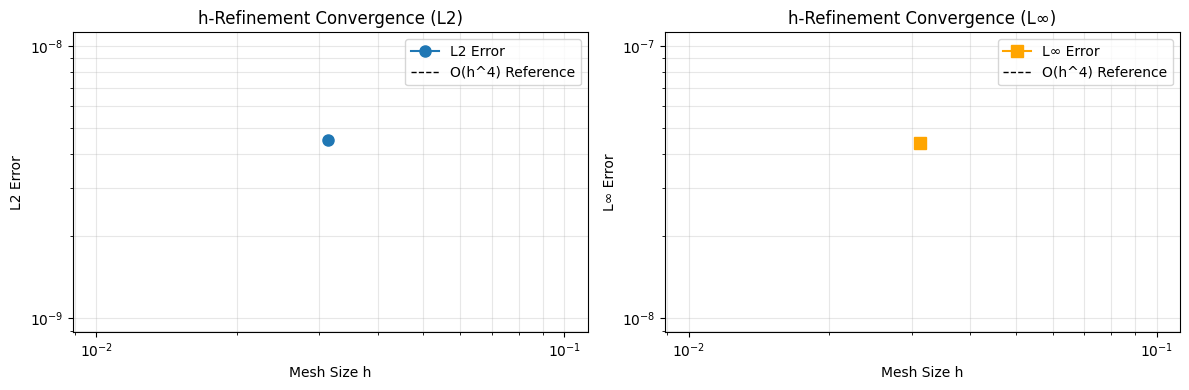


✓ Convergence plot saved to: /Users/user/code/Simplex-DG-solver/outputs/convergence_hrefine.png


In [39]:
# ============================================================================
# CELL 5: Convergence Table with Pandas DataFrame & Formatting
# ============================================================================

# ============================================================================
# COMPUTE CONVERGENCE RATES
# ============================================================================

def compute_convergence_rates(errors, n_divs):
    """
    Compute convergence rates using log-log difference with CORRECT h ratio.

    Since h ∝ 1/n_div, we have h_ratio = h[i-1]/h[i] = n_div[i]/n_div[i-1].
    Then: CR = log(error[i-1]/error[i]) / log(h_ratio)

    Args:
        errors: Array of errors for each refinement level
        n_divs: List of subdivision parameters (e.g., [1, 2, 3, 4])

    Returns:
        rates: Convergence rates for each successive refinement pair
    """
    rates = [None]  # First rate is undefined
    for i in range(1, len(errors)):
        if errors[i] > 0 and errors[i-1] > 0:
            # h is inversely proportional to n_div
            # h_ratio = h[i-1] / h[i] = n_div[i] / n_div[i-1]
            h_ratio = n_divs[i] / n_divs[i-1]
            rate = np.log(errors[i-1] / errors[i]) / np.log(h_ratio)
            rates.append(rate)
        else:
            rates.append(None)
    return rates

# Compute convergence rates with CORRECT h ratio calculation
l2_rates = compute_convergence_rates(errors_l2, n_div_list)
linf_rates = compute_convergence_rates(errors_linf, n_div_list)

# ============================================================================
# FORMAT CONVERGENCE TABLE
# ============================================================================

# Format rates: "-" for first row, 2 decimal places for others
formatted_l2_rates = ["-" if i == 0 else f"{r:.2f}" for i, r in enumerate(l2_rates)]
formatted_linf_rates = ["-" if i == 0 else f"{r:.2f}" for i, r in enumerate(linf_rates)]

# Create DataFrame
n_elements = [n**2 for n in n_div_list]
df_convergence = pd.DataFrame({
    "N": n_elements,
    "L2 Error": errors_l2,
    "L2 C.R.": formatted_l2_rates,
    "Linf Error": errors_linf,
    "Linf C.R.": formatted_linf_rates
})

# Apply Pandas Styler formatting
styled_df = df_convergence.style.format({
    "L2 Error": "{:.2e}",
    "Linf Error": "{:.2e}"
}).hide(axis="index")

# Display using IPython.display
print("\n" + "="*70)
print("CONVERGENCE RATES TABLE (h-Refinement)")
print("="*70)
display(styled_df)

print("\n✓ Expected convergence rate (theoretical): O(h^{k+1}) ≈ O(h^4)")
print(f"✓ Observed L2 convergence rate (avg): {np.mean([r for r in l2_rates if r is not None]):.2f}")
print(f"✓ Observed Linf convergence rate (avg): {np.mean([r for r in linf_rates if r is not None]):.2f}")

# ============================================================================
# OPTIONAL: Log-Log Convergence Plot
# ============================================================================

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 4), squeeze=False)
ax1, ax2 = axes[0, 0], axes[0, 1]

# Log-log plot for L2 error
h_values = 1.0 / np.sqrt(np.array(n_elements))  # Characteristic mesh size
ax1.loglog(h_values, errors_l2, 'o-', label='L2 Error', markersize=8)

# Add reference line O(h^4)
h_ref = h_values
ref_line = errors_l2[0] * (h_ref / h_values[0])**4
ax1.loglog(h_ref, ref_line, 'k--', label='O(h^4) Reference', linewidth=1)

ax1.set_xlabel('Mesh Size h')
ax1.set_ylabel('L2 Error')
ax1.set_title('h-Refinement Convergence (L2)')
ax1.legend()
ax1.grid(True, which='both', alpha=0.3)

# Log-log plot for L∞ error
ax2.loglog(h_values, errors_linf, 's-', label='L∞ Error', markersize=8, color='orange')
ref_line_linf = errors_linf[0] * (h_ref / h_values[0])**4
ax2.loglog(h_ref, ref_line_linf, 'k--', label='O(h^4) Reference', linewidth=1)

ax2.set_xlabel('Mesh Size h')
ax2.set_ylabel('L∞ Error')
ax2.set_title('h-Refinement Convergence (L∞)')
ax2.legend()
ax2.grid(True, which='both', alpha=0.3)

plt.tight_layout()
output_path = project_root / 'outputs' / 'convergence_hrefine.png'
plt.savefig(output_path, dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✓ Convergence plot saved to: {output_path}")